In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns

from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

# Timing analysis

In [2]:
df_real = pd.read_parquet('df_plot_compar_orig.parquet')

df_synthetic= pd.read_parquet('df_plot_sintetic_timing.parquet')

In [3]:
df_real.Model = df_real.Model.replace({ 'XGBOOST':'XGB' })

df_synthetic.Model = df_synthetic.Model.replace({ 'XGBOOST':'XGB' })

In [45]:
df_real.columns

Index(['Model', 'n3_CI_mean', 'n3_CI_low', 'n3_CI_high', 'n2_CI_mean',
       'n2_CI_low', 'n2_CI_high', 'n1_CI_mean', 'n1_CI_low', 'n1_CI_high',
       'n0_CI_mean', 'n0_CI_low', 'n0_CI_high', 'missed_CI_low',
       'missed_CI_high', 'missed_CI_mean', 'Group'],
      dtype='object')

In [43]:
# --- 1. Style Setup ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42

metrics = ['n3', 'n2', 'n1', 'n0', 'missed']
labels = ['3 weeks earlier', '2 weeks earlier', '1 week earlier', 'Same week', 'Missed']

# Palettes (Real: Blue, Synth: Teal)
colors_real = ['#084594', '#2171b5', '#4292c6', '#9ecae1', '#d9d9d9']
colors_synth = ['#1d5257', '#3b7d8c', '#53b1cb', '#76d1e6', '#e3e3e3']
COLOR_DIFF_PLUS = '#2ca25f'
COLOR_DIFF_MINUS = '#dd1c77'

# --- 2. Data Consolidation (The Axis Fix) ---
# Standardize column casing before joining
df_real = df_real.rename(columns={'model': 'Model', 'group': 'Group', 'n3_per':'n3_CI_mean',
                                 'n2_per':'n2_CI_mean','n1_per':'n1_CI_mean','n0_per':'n0_CI_mean',
                                 'missed_per':'missed_CI_mean'}, errors='ignore')
df_synthetic = df_synthetic.rename(columns={'model': 'Model', 'group': 'Group'}, errors='ignore')

# Merge into a single master layout DataFrame using real data as the structural anchor
df_master = pd.merge(
    df_real, 
    df_synthetic, 
    on=['Group', 'Model'], 
    suffixes=('_real', '_synth')
)

# Sort the MASTER dataframe explicitly so that both real and synthetic rows track together
# Sorting by Group first keeps EADMs and Meta-classifiers clustered together
df_master = df_master.sort_values(by=['Group', 'n3_CI_mean_real'], ascending=[True, False]).reset_index(drop=True)


/tmp/ipykernel_3678175/1609605447.py:95: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(colors_real, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False, fontsize=9, columnspacing=1.0)
/tmp/ipykernel_3678175/1609605447.py:96: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax2.legend(colors_synth, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False, fontsize=9, columnspacing=1.0)


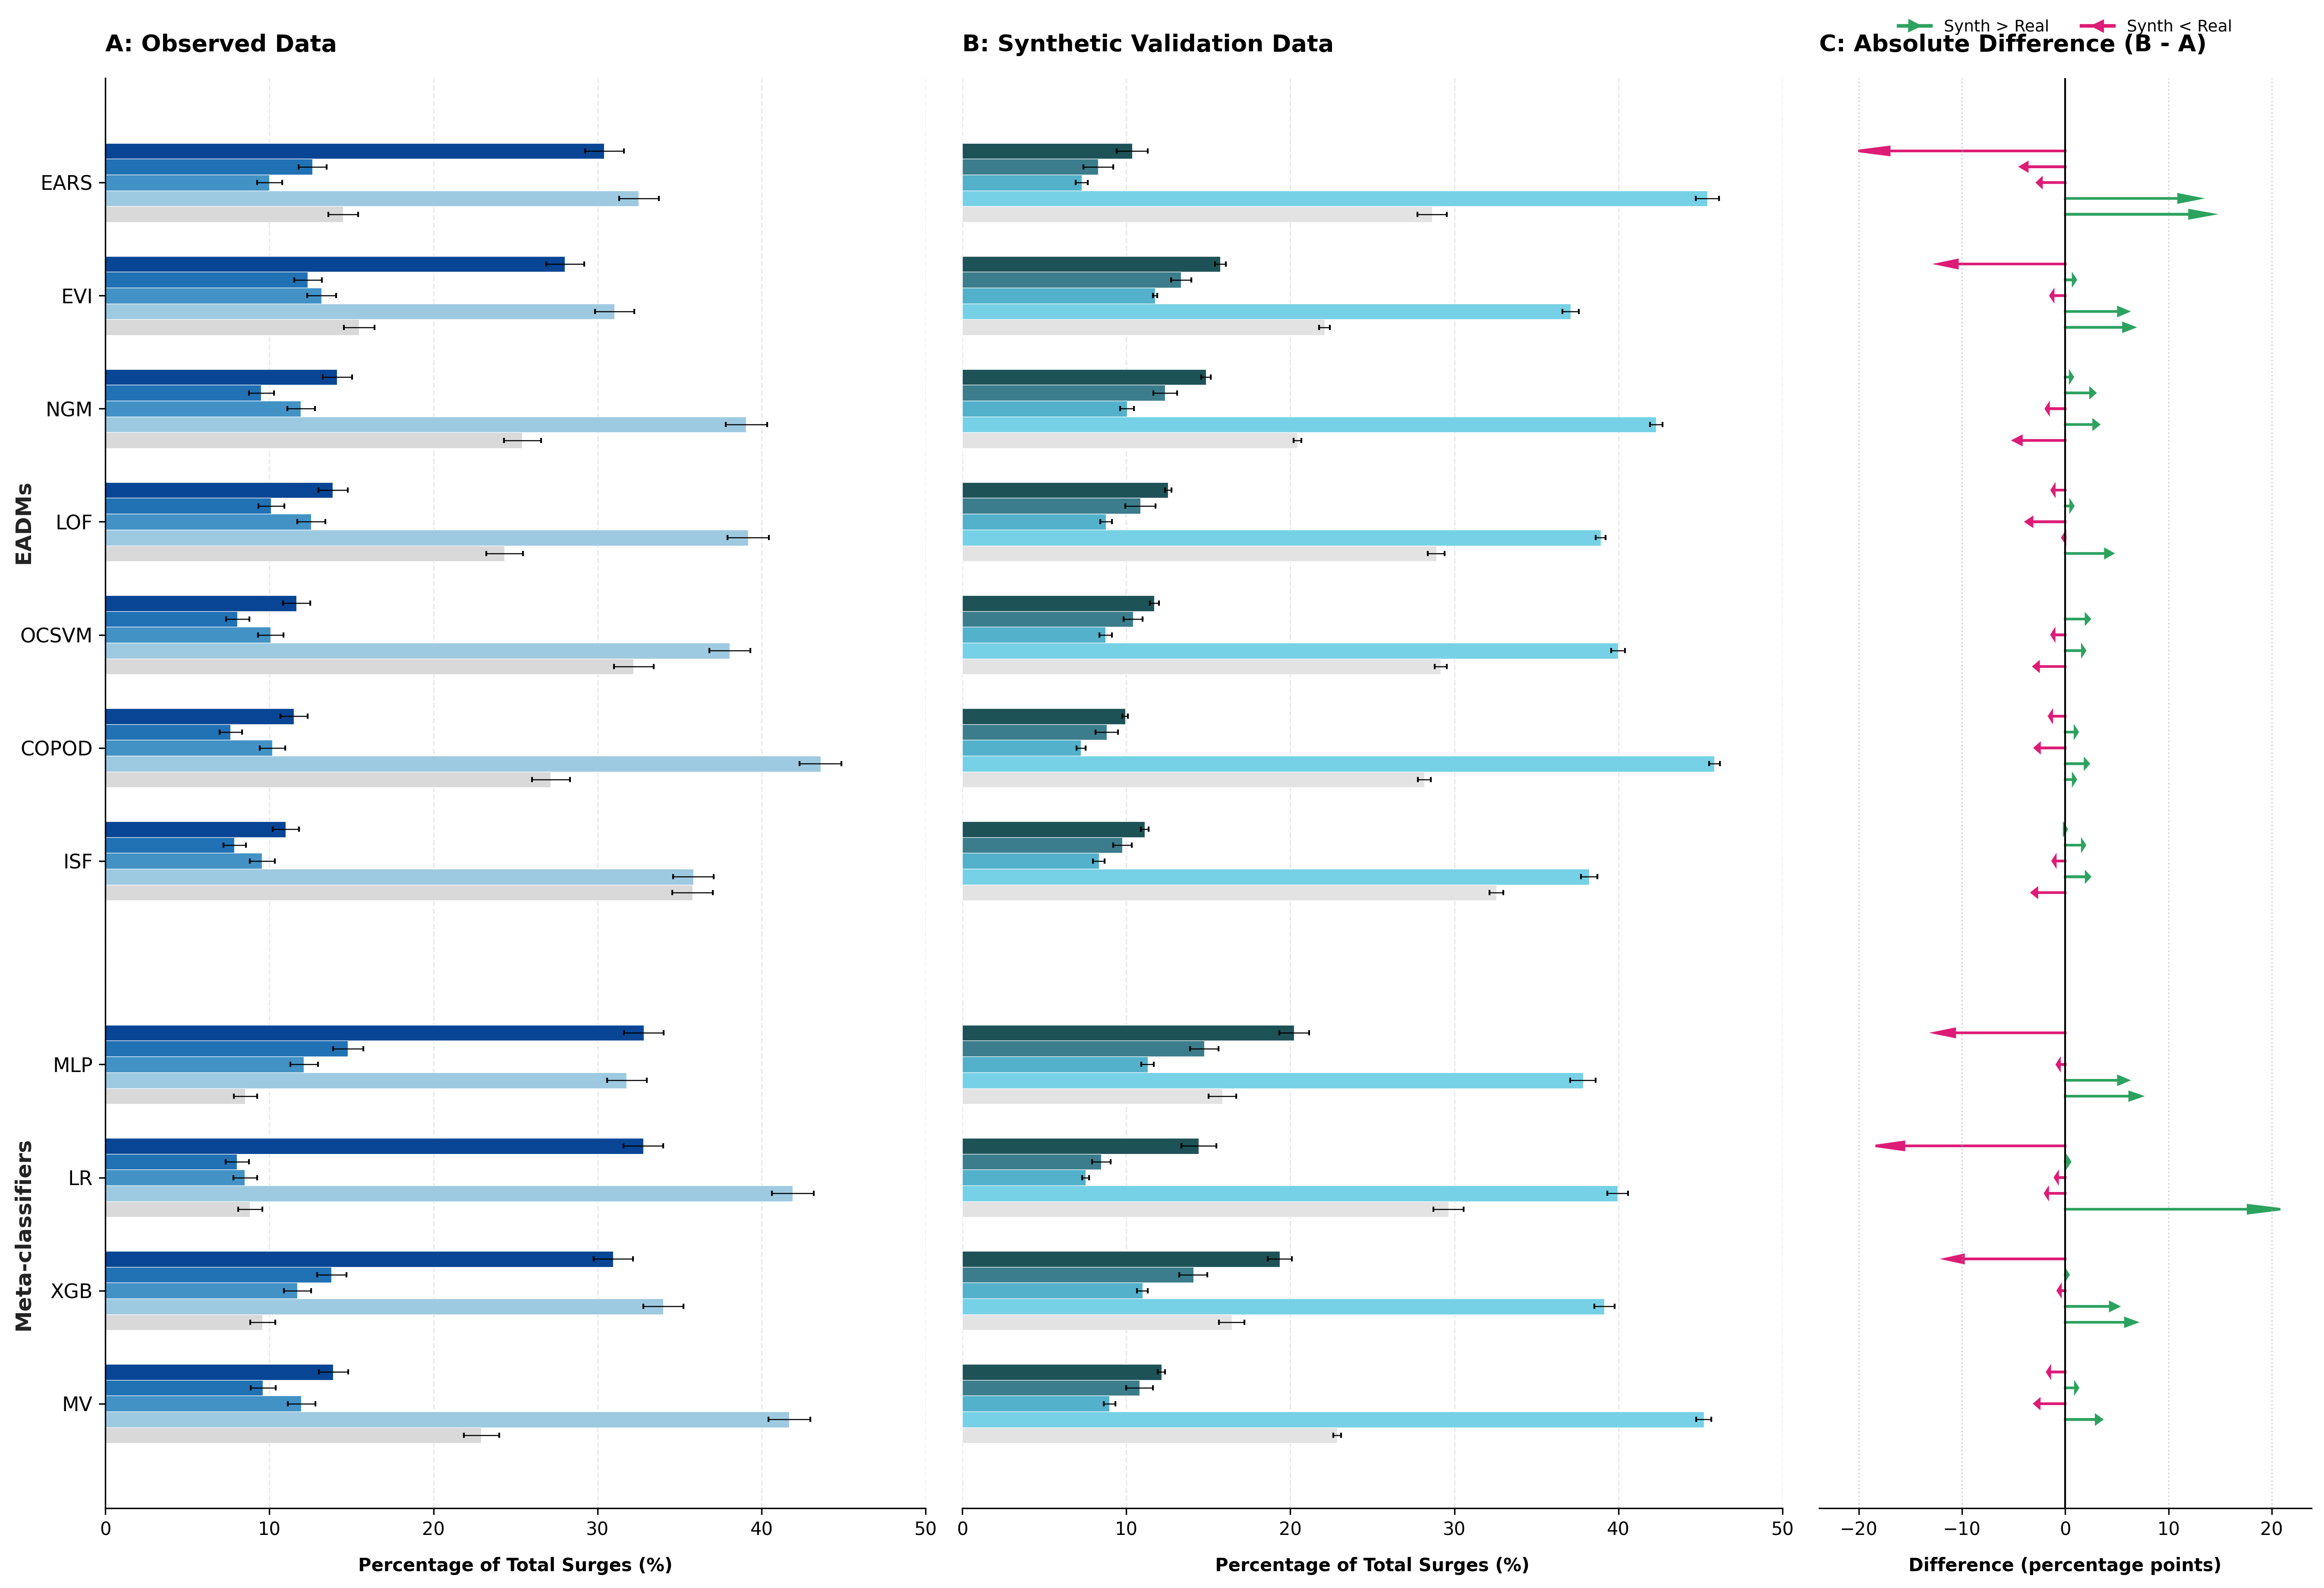

In [46]:
# --- 3. Positional Math ---
bar_height = 0.14
indices = []
current_pos = 0

for i in range(len(df_master)):
    if i > 0 and df_master.iloc[i]['Group'] != df_master.iloc[i-1]['Group']:
        current_pos += 0.8  # Gap between EADMs and Meta-classifiers
    indices.append(current_pos)
    current_pos += 1

indices = np.array(indices)

# --- 4. Subplot Grid Layout Construction ---
fig = plt.figure(figsize=(18, 13), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.6])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

# --- 5. Plotting Engine ---
for i, metric in enumerate(metrics):
    pos = indices + (i * bar_height)
    
    # Real Data (Fixed keys to use _real suffix)
    mean_real = df_master[f'{metric}_CI_mean_real']
    err_real = [mean_real - df_master[f'{metric}_CI_low_real'], df_master[f'{metric}_CI_high_real'] - mean_real]
    ax1.barh(pos, mean_real, bar_height, color=colors_real[i], edgecolor='white', linewidth=0.3)
    ax1.errorbar(mean_real, pos, xerr=err_real, fmt='none', ecolor='black', capsize=1.5, elinewidth=0.6)
    
    # Synthetic Data (Fixed keys to use _synth suffix)
    mean_synth = df_master[f'{metric}_CI_mean_synth']
    err_synth = [mean_synth - df_master[f'{metric}_CI_low_synth'], df_master[f'{metric}_CI_high_synth'] - mean_synth]
    ax2.barh(pos, mean_synth, bar_height, color=colors_synth[i], edgecolor='white', linewidth=0.3)
    ax2.errorbar(mean_synth, pos, xerr=err_synth, fmt='none', ecolor='black', capsize=1.5, elinewidth=0.6)
    
    # --- 6. Plotting Panel C (True Vector Differences) ---
    diff_values = mean_synth - mean_real
    
    for idx, diff_val in enumerate(diff_values):
        y_loc = pos[idx]
        
        if abs(diff_val) > 0.1:  # Filter out trivial margins
            arrow_color = COLOR_DIFF_PLUS if diff_val > 0 else COLOR_DIFF_MINUS
            
            ax3.arrow(
                0, y_loc, diff_val, 0, 
                length_includes_head=True, 
                head_width=0.07, 
                head_length=abs(diff_val) * 0.15 if abs(diff_val) > 2 else 0.25,
                color=arrow_color, 
                linewidth=1.4
            )

# --- 7. Formatting Panel Aesthetics ---
center_y = indices + (bar_height * (len(metrics)-1) / 2)
ax1.set_yticks(center_y)
ax1.set_yticklabels(df_master['Model'], fontsize=11)
ax1.invert_yaxis()

ax1.set_title("A: Observed Data", loc='left', fontsize=13, fontweight='bold', pad=15)
ax2.set_title("B: Synthetic Validation Data", loc='left', fontsize=13, fontweight='bold', pad=15)
ax3.set_title("C: Absolute Difference (B - A)", loc='left', fontsize=13, fontweight='bold', pad=15)

for ax in [ax1, ax2]:
    ax.set_xlabel('Percentage of Total Surges (%)', fontsize=10, fontweight='bold', labelpad=10)
    ax.set_xlim(0, 50)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)

ax3.set_xlabel('Difference (percentage points)', fontsize=10, fontweight='bold', labelpad=10)
ax3.axvline(x=0, color='black', linewidth=1.0, linestyle='-')
ax3.xaxis.grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')

# Re-calculate safe, symmetric x-limits for Panel C dynamically
max_diff = max(abs(df_master[f'{m}_CI_mean_synth'] - df_master[f'{m}_CI_mean_real']).max() for m in metrics)
ax3.set_xlim(-max_diff - 3, max_diff + 3)

# Strip redundant borders
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax != ax1:
        ax.tick_params(labelleft=False, left=False)
        ax.spines['left'].set_visible(False)

# --- 8. Group Labels ---
for group in df_master['Group'].unique():
    group_indices = indices[df_master['Group'] == group]
    avg_pos = group_indices.mean() + (bar_height * 2)
    ax1.text(-5, avg_pos, group, fontweight='bold', fontsize=12, rotation=90, va='center', ha='center', color='#222222')

# --- 9. Clean Legend Layout ---
ax1.legend(colors_real, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False, fontsize=9, columnspacing=1.0)
ax2.legend(colors_synth, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False, fontsize=9, columnspacing=1.0)

diff_elements = [
    Line2D([0], [0], color=COLOR_DIFF_PLUS, lw=2, marker='>', markersize=6, label='Synth > Real'),
    Line2D([0], [0], color=COLOR_DIFF_MINUS, lw=2, marker='<', markersize=6, label='Synth < Real')
]
ax3.legend(handles=diff_elements, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/comparative_timing.png', bbox_inches='tight')
plt.show()

In [85]:
round(df_real_sorted[['Model', 'n3_per', 'n3_CI_low', 'n3_CI_high']],1)

,Model,n3_per,n3_CI_low,n3_CI_high
0,EARS,30.4,29.2,31.6
1,EVI,28.0,26.9,29.2
2,NGM,14.1,13.2,15.0
3,LOF,13.9,13.0,14.8
4,OCSVM,11.6,10.8,12.5
5,COPOD,11.5,10.7,12.3
6,ISF,11.0,10.2,11.8
7,MLP,32.8,31.6,34.0
8,LR,32.8,31.6,34.0
9,XGB,30.9,29.8,32.2


In [87]:
df_real_sorted.Model.unique().to_list()

/tmp/ipykernel_3634095/4041832173.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  df_real_sorted.Model.unique().to_list()


['EARS',
 'EVI',
 'NGM',
 'LOF',
 'OCSVM',
 'COPOD',
 'ISF',
 'MLP',
 'LR',
 'XGB',
 'MV']

In [90]:
df_real_sorted[df_real_sorted.Model.isin(['EARS',
 'EVI',
 'NGM',
 'LOF',
 'OCSVM',
 'COPOD',
 'ISF'])][[ 'n3_per', 'n3_CI_low', 'n3_CI_high']].mean()

n3_per        17.214719
n3_CI_low     16.294387
n3_CI_high    18.178715
dtype: float64

In [91]:
df_real_sorted[df_real_sorted.Model.isin(['MLP',
 'LR',
 'XGB'])][[ 'n3_per', 'n3_CI_low', 'n3_CI_high']].mean()

n3_per        32.182712
n3_CI_low     30.989211
n3_CI_high    33.399942
dtype: float64

In [95]:
round(32.182712 - 17.214719,1)

15.0

In [96]:
df_real_sorted.columns

Index(['Model', 'n3_per', 'n3_CI_low', 'n3_CI_high', 'n2_per', 'n2_CI_low',
       'n2_CI_high', 'n1_per', 'n1_CI_low', 'n1_CI_high', 'n0_per',
       'n0_CI_low', 'n0_CI_high', 'missed_CI_low', 'missed_CI_high',
       'missed_per', 'Group'],
      dtype='object')

In [97]:
round(df_real_sorted[['Model','missed_per','missed_CI_low', 'missed_CI_high']],1)

,Model,missed_per,missed_CI_low,missed_CI_high
0,EARS,14.5,13.6,15.4
1,EVI,15.5,14.5,16.4
2,NGM,25.4,24.3,26.6
3,LOF,24.3,23.2,25.4
4,OCSVM,32.2,31.0,33.4
5,COPOD,27.1,26.0,28.3
6,ISF,35.8,34.6,37.0
7,MLP,8.5,7.8,9.3
8,LR,8.8,8.1,9.6
9,XGB,9.6,8.8,10.4


In [8]:
df_synthetic_sorted.columns

Index(['Model', 'n3_CI_mean', 'n3_CI_low', 'n3_CI_high', 'n2_CI_mean',
       'n2_CI_low', 'n2_CI_high', 'n1_CI_mean', 'n1_CI_low', 'n1_CI_high',
       'n0_CI_mean', 'n0_CI_low', 'n0_CI_high', 'missed_CI_mean',
       'missed_CI_low', 'missed_CI_high', 'Group'],
      dtype='object')

In [9]:
df_synthetic_sorted[df_synthetic_sorted.Model.isin(['EARS',
 'EVI',
 'NGM',
 'LOF',
 'OCSVM',
 'COPOD',
 'ISF'])][[ 'n3_CI_mean', 'n3_CI_low', 'n3_CI_high']].mean()

n3_CI_mean    12.323343
n3_CI_low     11.971757
n3_CI_high    12.674929
dtype: float64

In [10]:
df_synthetic_sorted[df_synthetic_sorted.Model.isin(['MLP',
 'LR',
 'XGB'])][[ 'n3_CI_mean', 'n3_CI_low', 'n3_CI_high']].mean()

n3_CI_mean    18.004333
n3_CI_low     17.102467
n3_CI_high    18.906167
dtype: float64

In [26]:
round(df_synthetic_sorted[['Model', 'n3_CI_mean', 'n3_CI_low', 'n3_CI_high']],1)

,Model,n3_CI_mean,n3_CI_low,n3_CI_high
0,EVI,15.7,15.4,16.1
1,NGM,14.8,14.6,15.1
2,LOF,12.6,12.4,12.8
3,OCSVM,11.7,11.4,12.0
4,ISF,11.1,10.9,11.4
5,EARS,10.4,9.4,11.3
6,COPOD,9.9,9.7,10.1
7,MLP,20.2,19.3,21.1
8,XGB,19.4,18.6,20.1
9,LR,14.4,13.3,15.5


In [51]:
lst = []
for m in metrics:
     lst.append([ m, df_synthetic_sorted[f'{m}_CI_mean'] - df_real_sorted[f'{m}_per'] ] )

In [52]:
lst

[['n3',
  0    -14.672332
  1    -13.165777
  2     -1.564488
  3     -2.151997
  4     -0.513502
  5     -1.121388
  6     -1.050152
  7    -12.581934
  8    -13.422442
  9    -16.530760
  10    -1.737943
  dtype: float64],
 ['n2',
  0     0.736619
  1     0.038156
  2     1.382909
  3     0.321897
  4     1.712431
  5     0.680982
  6     0.954138
  7    -0.020338
  8     6.074723
  9    -5.294467
  10    1.229432
  dtype: float64],
 ['n1',
  0     1.757173
  1    -3.111855
  2    -3.154239
  3    -3.797597
  4    -1.728911
  5    -2.880688
  6    -2.298930
  7    -0.803146
  8     2.480734
  9    -4.175640
  10   -2.955485
  dtype: float64],
 ['n0',
  0      4.576495
  1     11.269510
  2     -0.148613
  3      0.785665
  4      0.161858
  5      1.829267
  6     10.014853
  7      6.061129
  8     -2.748120
  9      5.932289
  10     3.524033
  dtype: float64],
 ['missed',
  0      7.602045
  1      4.969966
  2      3.484431
  3      4.842133
  4      0.368024
  5      1.491826
  

In [50]:
round(df_synthetic_sorted[['Model','missed_CI_mean',
       'missed_CI_low', 'missed_CI_high']],1)

,Model,missed_CI_mean,missed_CI_low,missed_CI_high
0,EVI,22.1,21.8,22.4
1,NGM,20.4,20.2,20.7
2,LOF,28.9,28.4,29.4
3,OCSVM,29.2,28.8,29.5
4,ISF,32.6,32.1,33.0
5,EARS,28.6,27.7,29.5
6,COPOD,28.2,27.8,28.6
7,MLP,15.9,15.0,16.7
8,XGB,16.4,15.7,17.2
9,LR,29.6,28.7,30.6


In [48]:
df_synthetic_sorted[df_synthetic_sorted.Model.isin(['EARS',
 'EVI',
 'NGM',
 'LOF',
 'OCSVM',
 'COPOD',
 'ISF'])][[ 'missed_CI_mean',
       'missed_CI_low', 'missed_CI_high']].mean()

missed_CI_mean    27.133543
missed_CI_low     26.682214
missed_CI_high    27.584843
dtype: float64

In [49]:
df_synthetic_sorted[df_synthetic_sorted.Model.isin(['MLP',
 'LR',
 'XGB'])][[ 'missed_CI_mean',
       'missed_CI_low', 'missed_CI_high']].mean()

missed_CI_mean    20.643967
missed_CI_low     19.798833
missed_CI_high    21.489067
dtype: float64

# Metrics of performance

In [9]:
df_real = pd.read_parquet('df_plot_metrics_real.parquet')
df_synth = pd.read_parquet('df_plot_metrics_sint.parquet')

df_real.model = df_real.model.replace({ 'XGBOOST':'XGB' })

df_synth.model = df_synth.model.replace({ 'XGBOOST':'XGB' })

In [10]:
df_synth.columns

Index(['model', 'NPV_CI_mean', 'NPV_CI_low', 'NPV_CI_high', 'PPV_CI_mean',
       'PPV_CI_low', 'PPV_CI_high', 'Sensitivity _CI_mean',
       'Sensitivity _CI_low', 'Sensitivity _CI_high', 'Specificity_CI_mean',
       'Specificity_CI_low', 'Specificity_CI_high', 'Group'],
      dtype='object', name='Metric')

In [11]:
# 1. Create the pivot table as you did
df_pivot = pd.pivot_table(
    df_real, 
    values=['Estimate', 'CI_Low', 'CI_High'], 
    index=["model", "Group"], 
    columns=["Metric"], 
    aggfunc="sum"
)

# 2. Flatten the MultiIndex columns
# This converts columns like ('Estimate', 'NPV') into a single string 'Estimate_NPV'
df_pivot.columns = [f"{val}_{metric}" for val, metric in df_pivot.columns]

# 3. Reset the index so 'Model' and 'Group' become normal columns again
df_real_ready = df_pivot.reset_index()

# 4. Rename columns to match the format expected by the plotting loop
# Maps 'Estimate_NPV' -> 'NPV_per', 'CI_Low_NPV' -> 'NPV_CI_low', etc.
rename_dict = {}
metrics_list = ['NPV', 'PPV', 'Sensitivity', 'Specificity']

for m in metrics_list:
    rename_dict[f'Estimate_{m}'] = f'{m}_CI_mean'
    rename_dict[f'CI_Low_{m}']  = f'{m}_CI_low'
    rename_dict[f'CI_High_{m}'] = f'{m}_CI_high'

# Apply the renaming dictionary
df_real_ready = df_real_ready.rename(columns=rename_dict)

# 5. Fix the lowercase 'model' column name to 'Model' for global consistency
df_real_ready = df_real_ready.rename(columns={'model': 'Model'})

# Quick check to see the newly flattened format
print(df_real_ready.columns)

Index(['Model', 'Group', 'NPV_CI_high', 'PPV_CI_high', 'Sensitivity_CI_high',
       'Specificity_CI_high', 'NPV_CI_low', 'PPV_CI_low', 'Sensitivity_CI_low',
       'Specificity_CI_low', 'NPV_CI_mean', 'PPV_CI_mean',
       'Sensitivity_CI_mean', 'Specificity_CI_mean'],
      dtype='object')


In [12]:
df_synth = df_synth.rename(columns = {'Sensitivity _CI_mean': 'Sensitivity_CI_mean',
       'Sensitivity _CI_low': 'Sensitivity_CI_low', 'Sensitivity _CI_high':'Sensitivity_CI_high'})

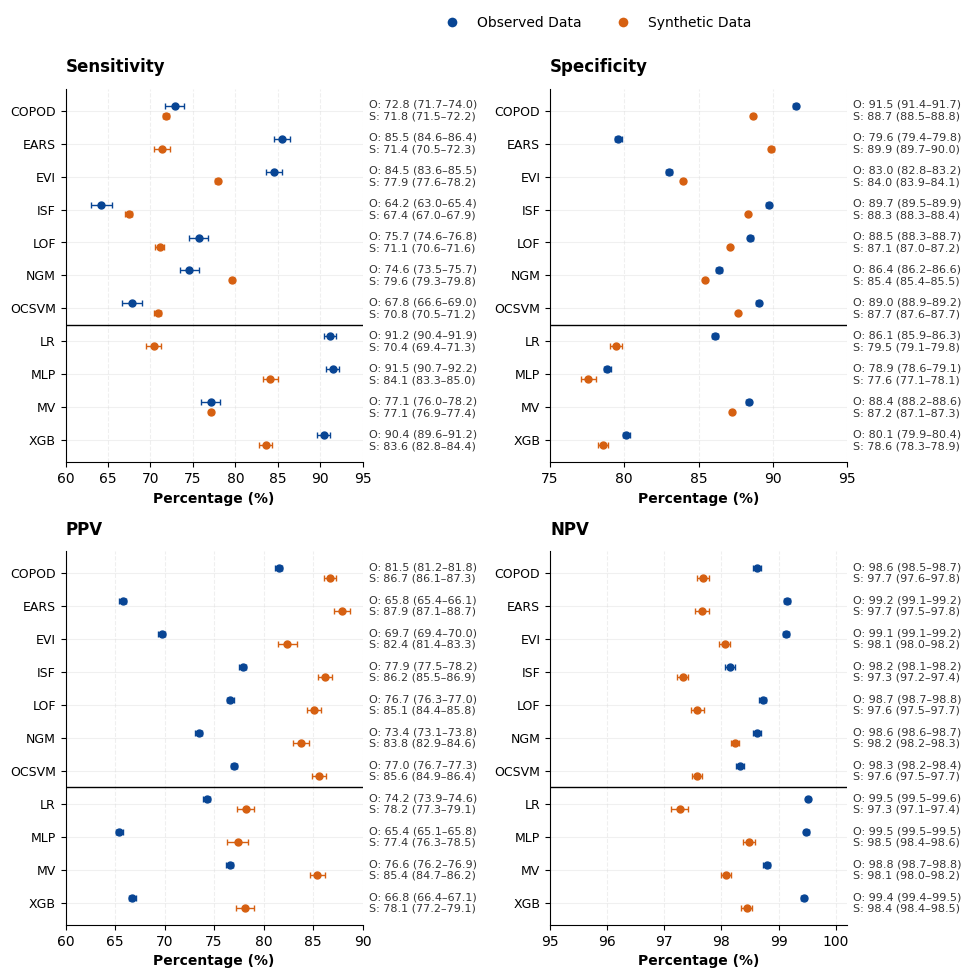

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# --- 1. Lancet-Style Typography & Theme Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8
})

#COLOR_REAL = '#084594'   # Deep Blue
#COLOR_SYNTH = '#006666'  # Deep Teal
COLOR_REAL  = '#084594'   # Classic Deep Blue
COLOR_SYNTH = '#D66011'   # Professional Rust Orange

# --- 2. Data Alignment Processing ---
# Standardize both dataframes to make sure names match case exactly
df_real_ready = df_real_ready.sort_values(by=['Group', 'Model'], ascending=[True, True]).reset_index(drop=True)
df_synth = df_synth.sort_values(by=['Group', 'model'], ascending=[True, True]).reset_index(drop=True)

# Use capitalized 'Model' to match your dataframe definitions
models = df_real_ready['Model'].tolist()
y_positions = np.arange(len(models))

# Calculate where the solid horizontal line splits EADMs and Meta-classifiers
split_idx = np.where(df_real_ready['Group'] != df_real_ready['Group'].shift(-1))[0][0]
line_y = (y_positions[split_idx] + y_positions[split_idx + 1]) / 2

# Define panels with custom axes limits to resolve compression
panels = [
    ('Sensitivity', 'Sensitivity', 60, 95),
    ('Specificity', 'Specificity', 75, 95),
    ('PPV', 'PPV', 60, 90),
    ('NPV', 'NPV', 95, 100.2)
]

# Set up the 2x2 multi-panel layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# --- 3. Plotting Execution ---
for p_idx, (title, metric, xmin, xmax) in enumerate(panels):
    ax = axes[p_idx]
    
    # Draw horizontal guidance lines
    for y_val in y_positions:
        ax.axhline(y=y_val, color='#f0f0f0', linestyle='-', linewidth=0.8, zorder=0)

    # FIXED: Enumerate lets us pull both the numeric index (idx) and model name (mod)
    for idx, mod in enumerate(models):
        
        # --- A. Plot Real Data Point ---
        # FIXED: Added [0] to get the pure scalar number instead of an ambiguous numpy array
        r_mean = df_real_ready[df_real_ready.Model == mod][f'{metric}_CI_mean'].unique()[0]
        r_low  = df_real_ready[df_real_ready.Model == mod][f'{metric}_CI_low'].unique()[0]
        r_high = df_real_ready[df_real_ready.Model == mod][f'{metric}_CI_high'].unique()[0]
        
        # Auto-scale decimal formats (0.85 -> 85%) if necessary
        if r_mean <= 1.0: r_mean, r_low, r_high = r_mean*100, r_low*100, r_high*100
        
        # FIXED: Now uses the correct 'idx' variable for vertical placement
        ax.errorbar(
            r_mean, idx - 0.15, xerr=[[r_mean - r_low], [r_high - r_mean]], 
            fmt='o', color=COLOR_REAL, markersize=5, capsize=2, elinewidth=1, zorder=3
        )
        
        # --- B. Plot Synthetic Validation Point ---
        # FIXED: Added [0] and aligned column references to 'Model'
        s_mean = df_synth[df_synth.model == mod][f'{metric}_CI_mean'].unique()[0]
        s_low  = df_synth[df_synth.model == mod][f'{metric}_CI_low'].unique()[0]
        s_high = df_synth[df_synth.model == mod][f'{metric}_CI_high'].unique()[0]
        
        if s_mean <= 1.0: s_mean, s_low, s_high = s_mean*100, s_low*100, s_high*100
        
        # FIXED: Replaced the hardcoded '11 + 0.15' with 'idx + 0.15'
        ax.errorbar(
            s_mean, idx + 0.15, xerr=[[s_mean - s_low], [s_high - s_mean]], 
            fmt='o', color=COLOR_SYNTH, markersize=5, capsize=2, elinewidth=1, zorder=3
        )
        
        # --- C. Add Clean Values Strings on the Margin ---
        # FIXED: Cleaned up the formatting syntax to print nicely as strings
        text_str = f"O: {r_mean:.1f} ({r_low:.1f}–{r_high:.1f})\nS: {s_mean:.1f} ({s_low:.1f}–{s_high:.1f})"
        ax.text(xmax + (xmax - xmin)*0.02, idx, text_str, va='center', ha='left', fontsize=8, color='#333333')

    # --- 4. Individual Axis Aesthetics ---
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Percentage (%)', fontsize=10, fontweight='bold')
    ax.set_xlim(xmin, xmax)
    
    # Draw group break divider line
    ax.axhline(y=line_y, color='black', linewidth=1.0, zorder=4)
    
    # Clean ticks and borders
    ax.set_yticks(y_positions)
    ax.set_yticklabels(models, fontsize=9)
    ax.invert_yaxis()  # Keep EADMs tracking up top
    
    ax.xaxis.grid(True, linestyle='--', color='#e0e0e0', alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# --- 5. Global Legend Configuration ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_REAL, markersize=8, label='Observed Data'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SYNTH, markersize=8, label='Synthetic Data')
]

fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.98), 
    ncol=2, 
    frameon=False, 
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.82, 0.94]) 
plt.show()

In [ ]:
1,240 (95% CI 1,213–1,267) synthetic outbreaks of low-intensity; 862 (95% CI: 840–883) of medium-intensity; 371 (95% CI: 359–383) of high-intensity; 1,006 (95% CI: 960–1,052) of very-high-intensity surges, and 4,149 (95% CI: 3,923–4,376) 




In [1]:
1240 + 862 + 371 + 1006 + 4149

7628

In [2]:
round((1240 + 862 + 371 + 1006)*100/7628,1)

45.6